In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [3]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

In [4]:
files_F222 = []
files_F223 = []
files_F231 = []
files_F232 = []
files_F241 = []
files_tungsten = []
files_F242 = []
files_caloNu = []
files_F243 = []

data_files = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists4/*.root")
for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])
    if runs_F222[0] <= run_num <= runs_F222[1]:
        files_F222.append(file)
    elif runs_F223[0] <= run_num <= runs_F223[1]:
        files_F223.append(file)
    elif runs_F231[0] <= run_num <= runs_F231[1]:
        files_F231.append(file)
    elif runs_F232[0] <= run_num <= runs_F232[1]:
        files_F232.append(file)
    elif runs_F241[0] <= run_num <= runs_F241[1]:
        files_F241.append(file)
    elif runs_tungsten[0] <= run_num <= runs_tungsten[1]:
        files_tungsten.append(file)
    elif runs_F242[0] <= run_num <= runs_F242[1]:
        files_F242.append(file)
    elif runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        files_caloNu.append(file)
    elif runs_F243[0] <= run_num <= runs_F243[1]:
        files_F243.append(file)

print(f"Files for F222: {len(files_F222)}")
print(f"Files for F223: {len(files_F223)}")
print(f"Files for F231: {len(files_F231)}")
print(f"Files for F232: {len(files_F232)}")
print(f"Files for F241: {len(files_F241)}")
print(f"Files for tungsten: {len(files_tungsten)}")
print(f"Files for F242: {len(files_F242)}")
print(f"Files for caloNu: {len(files_caloNu)}")
print(f"Files for F243: {len(files_F243)}")

Files for F222: 95
Files for F223: 83
Files for F231: 61
Files for F232: 28
Files for F241: 49
Files for tungsten: 43
Files for F242: 31
Files for caloNu: 130
Files for F243: 23


In [5]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [6]:
lumi_F222 = grl_df[grl_df["Run"].between(runs_F222[0], runs_F222[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F223 = grl_df[grl_df["Run"].between(runs_F223[0], runs_F223[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F231 = grl_df[grl_df["Run"].between(runs_F231[0], runs_F231[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F232 = grl_df[grl_df["Run"].between(runs_F232[0], runs_F232[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1

lumi_F241 = grl_df[grl_df["Run"].between(runs_F241[0], runs_F241[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_tungsten = grl_df[grl_df["Run"].between(runs_tungsten[0], runs_tungsten[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F242 = grl_df[grl_df["Run"].between(runs_F242[0], runs_F242[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_caloNu = grl_df[grl_df["Run"].between(runs_caloNu[0], runs_caloNu[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F243 = grl_df[grl_df["Run"].between(runs_F243[0], runs_F243[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1

print(f"Luminosity for F222: {lumi_F222:.3f} fb^-1")
print(f"Luminosity for F223: {lumi_F223:.3f} fb^-1")
print(f"Luminosity for F231: {lumi_F231:.3f} fb^-1")
print(f"Luminosity for F232: {lumi_F232:.3f} fb^-1")
print(f"Luminosity for F241: {lumi_F241:.3f} fb^-1")
print(f"Luminosity for tungsten: {lumi_tungsten:.3f} fb^-1")
print(f"Luminosity for F242: {lumi_F242:.3f} fb^-1")
print(f"Luminosity for caloNu: {lumi_caloNu:.3f} fb^-1")
print(f"Luminosity for F243: {lumi_F243:.3f} fb^-1")

Luminosity for F222: 9.700 fb^-1
Luminosity for F223: 27.289 fb^-1
Luminosity for F231: 20.473 fb^-1
Luminosity for F232: 9.225 fb^-1
Luminosity for F241: 11.522 fb^-1
Luminosity for tungsten: 17.449 fb^-1
Luminosity for F242: 9.772 fb^-1
Luminosity for caloNu: 70.033 fb^-1
Luminosity for F243: 11.354 fb^-1


In [7]:
hists_to_sum = [
    "crossingAngle"
]

In [8]:
hist_dict = {
    "F222": {"files": files_F222, "lumi": lumi_F222, "hists": {}, "colour":"lightcoral"},
    "F223": {"files": files_F223, "lumi": lumi_F223, "hists": {}, "colour":"firebrick"},
    "F231": {"files": files_F231, "lumi": lumi_F231, "hists": {}, "colour":"olive"},
    "F232": {"files": files_F232, "lumi": lumi_F232, "hists": {}, "colour": "olivedrab"},
    "F241": {"files": files_F241, "lumi": lumi_F241, "hists": {}, "colour":"teal"},
    "tungsten": {"files": files_tungsten, "lumi": lumi_tungsten, "hists": {}, "colour":"lightblue"},
    "F242": {"files": files_F242, "lumi": lumi_F242, "hists": {}, "colour":"steelblue"},
    "caloNu": {"files": files_caloNu, "lumi": lumi_caloNu, "hists": {}, "colour":"magenta"},
    "F243": {"files": files_F243, "lumi": lumi_F243, "hists": {}, "colour":"purple"}
}

In [9]:
def sum_histograms(histograms):
    summed_hist = None
    for hist in tqdm(histograms):
        if summed_hist is None:
            summed_hist = hist.to_boost()
        else:
            summed_hist += hist.to_boost()
    return summed_hist

In [10]:
for period, data in hist_dict.items():
    histograms = []
    for file in tqdm(data["files"]):
        with uproot.open(file) as f:

            try:
                hist_folder = f["histograms"]
            except Exception as e:
                print(f"Warning: 'histograms' folder not found in {file}. Skipping this file. {f.keys()}")
                continue

            for hist_name in hists_to_sum:
                if hist_name in hist_folder:
                    hist = hist_folder[hist_name]
                    histograms.append(hist)
    summed_hist = sum_histograms(histograms)
    data["hists"] = {hist_name: summed_hist for hist_name in hists_to_sum}

  0%|          | 0/95 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:00<00:00, 5272.97it/s]


/tmp/ipykernel_1385410/2906200007.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


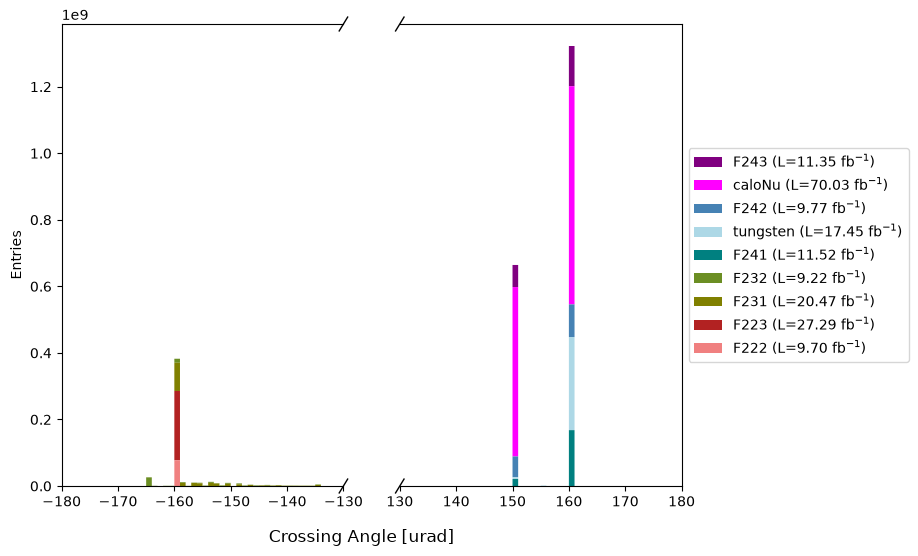

In [11]:
import matplotlib.pyplot as plt
import mplhep

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(8, 6), sharey=True,
    # gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.05}
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.2}
)

hists = []
labels = []
colours = []
for period, data in hist_dict.items():
    summed_hist = data["hists"]["crossingAngle"]
    hists.append(summed_hist)
    labels.append(rf"{period} (L={data['lumi']:.2f} $\text{{fb}}^{{-1}}$)")
    colours.append(data["colour"])

# plot the same data on both axes
mplhep.histplot(hists, ax=ax1, label=labels, density=False, histtype='fill', linewidth=1.5, stack=True, color=colours)
mplhep.histplot(hists, ax=ax2, label=labels, density=False, histtype='fill', linewidth=1.5, stack=True, color=colours)

# left half: -400 to -100
ax1.set_xlim(-180, -130)
# right half: 100 to 400
ax2.set_xlim(130, 180)

# ax1.set_yscale("log")
# ax2.set_yscale("log")

# hide the "inner" spines
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False, labelleft=False)

# diagonal break marks
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

ax1.set_ylabel("Entries")
fig.supxlabel("Crossing Angle [urad]")
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# rotate x-axis labels for better readability
# for ax in [ax1, ax2]:
#     plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()

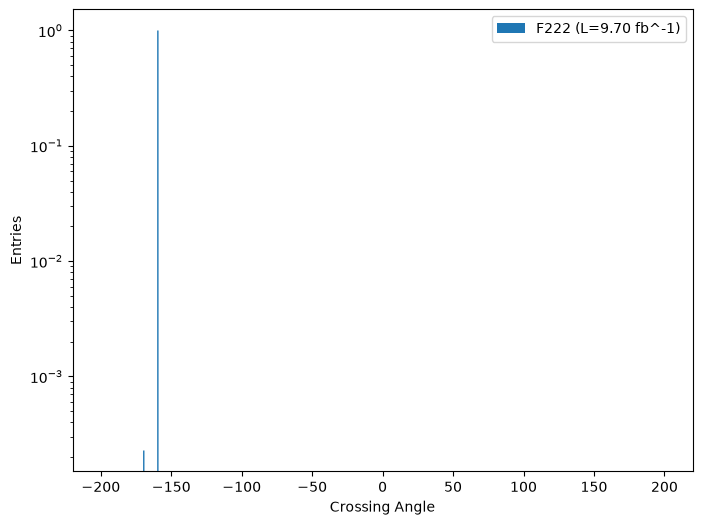

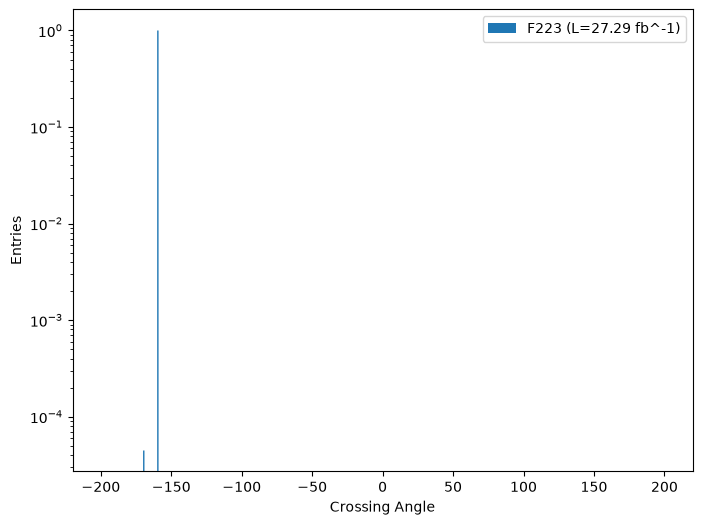

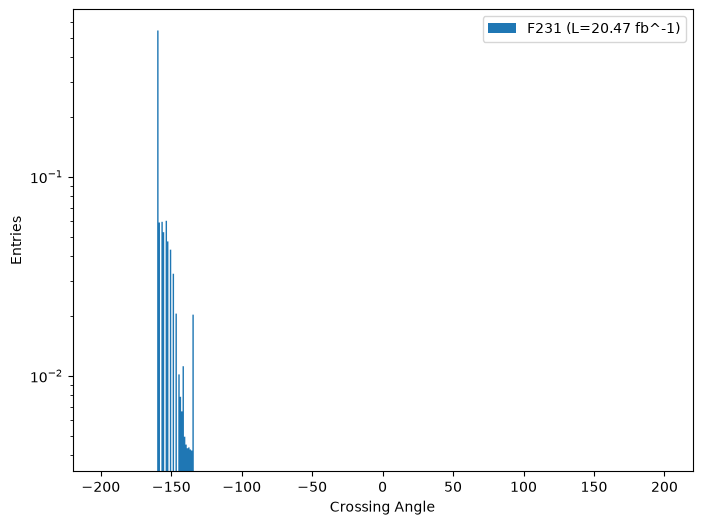

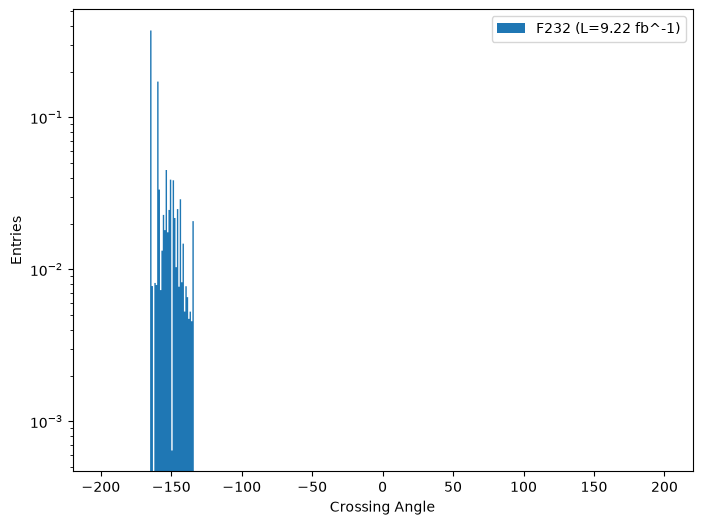

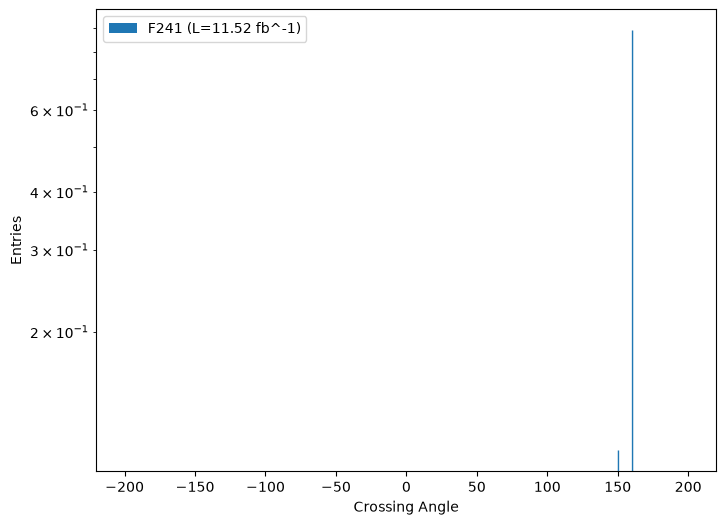

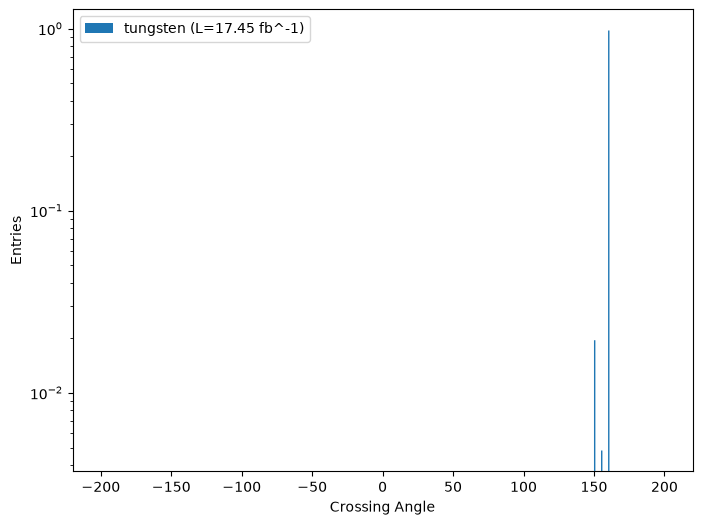

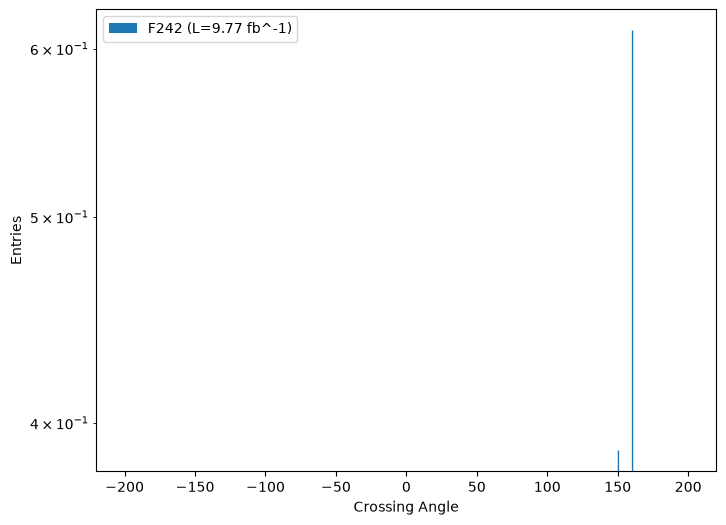

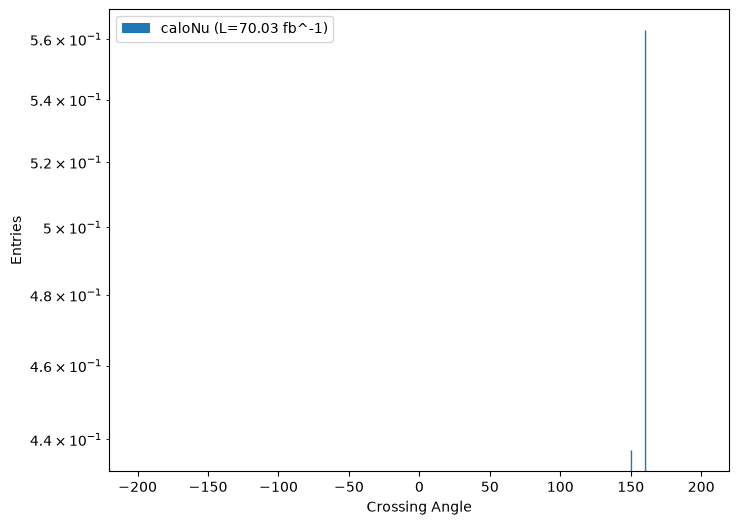

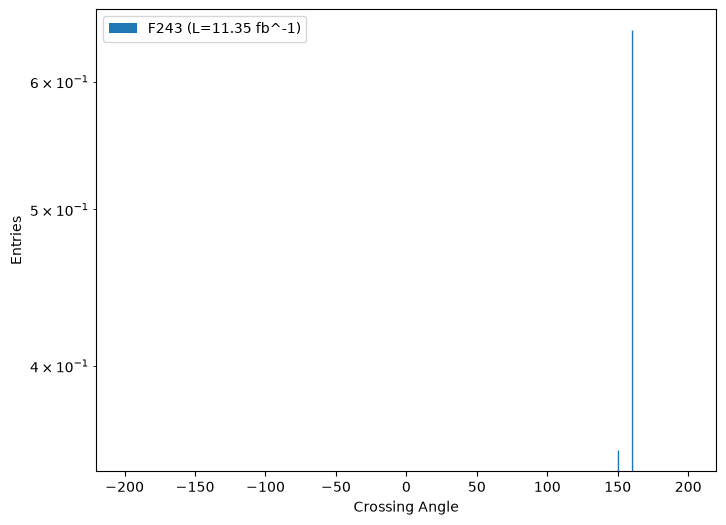

In [12]:

for period, data in hist_dict.items():
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    summed_hist = data["hists"]["crossingAngle"]
    mplhep.histplot(summed_hist, ax=ax, label=f"{period} (L={data['lumi']:.2f} fb^-1)", density=True, histtype='fill', linewidth=1.5)
    ax.set_xlabel("Crossing Angle")
    ax.set_ylabel("Entries")
    ax.set_yscale("log")
    ax.legend()